# **Workshop 2/8:** Time Series Generation (Simulation)

### Ural Federal University, Time Series Analysis

## 1. Data Import

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
# Use seaborn style defaults and set the default figure size
sns.set(rc={'figure.figsize':(16, 4)})

## 2. Deterministic Models

### 2.1 The Time Series model

<font size=4  face = 'Georgia' style='Line-height : 2em'>    
   
The Simplest case of Deterministic Time series is the 1-dimensional (univariate) value-to-time dependence, given in the following form <br>
    $$ y(t) = a_0 + trend(t)+ cyclic(t) +seasonal(t) $$
 where <blockquote>
<li> $y(t)$ is the series - the set of samples indexed by some variable t, usually $t$ is the time-steps, <ul>if time-step discreet it can be also denoted as $n$ (sample number), <br> in this case real time-step value will corresponds to $t=n\cdot T_s$,<ul> where $T_s$ is the period of step $n$ (sampling period with which samples are taken).</ul></ul></li>
<li> $a_0$ is some start constant level <br>
<li> $trend$ is the presence of some trend, which is the slow change part of the dependence.  <br>
<li> $seasonal$ is the seasonality or some "relatively rapidly change" periodic-like components - is a relatively fast-changing part of the relation. <br>
<li> $cyclic$ is the some "relatively slow change" periodic-like components with irregular period and relatively high intensity . </blockquote>
Often the $cyclic$ and  $a_0$ parts are included into $trend$, in this case the model can be given as
    $$ y(t) = trend(t) +seasonal(t). $$  

### 2.2 Trend investigation

> Indented block



<font size=4  face = 'Georgia' style='Line-height : 2em'>
    
For the first let's simulate Time series as only linear trend, taken with uniform period of sampling.
    

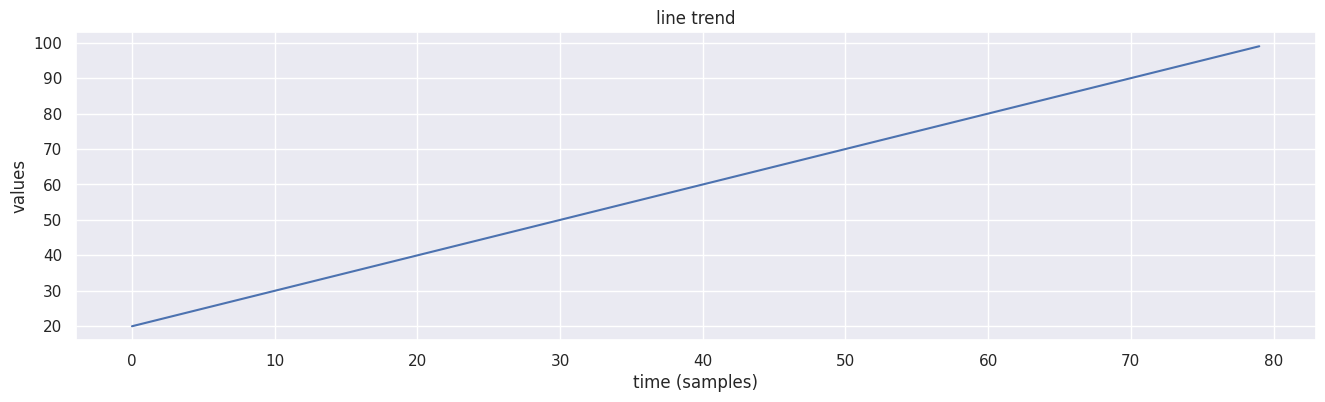

In [ ]:
ts = np.arange(20,100)
fig, ax = plt.subplots()
ax.plot(ts)
ax.set(xlabel='time (samples)', ylabel='values',
       title='line trend')
plt.show()

<font size=4  face = 'Georgai' style='Line-height : 2em'>
    
There are a several simplest <b>types of the trends</b> can be introduced within time series:<ul>
<li> line trend $y(t) = a\cdot t + b$
<li> parabolic trend $y(t) = a\cdot t^2 + b \cdot x + c$
<li> polynomial trend $y(t) = a\cdot t^b + c$
<li> hyperbolic trend $y(t) = \frac{a}{t^b+c} + d$
<li> exponential trend $y(t) = \exp{(a\cdot t+b)}$
<li> saturating(logistic) trend  $y(t) = \frac{c}{1+exp(-k(t-m))}$    
<li> logarithmic trend $y(t) = c\log_b{(a\cdot t)}$
<li> many other functions  that are, as a rule, smoothed, very slow changed or even monotonic.
</ul>   
Now we may try logarithmic trend with $e$ base ( Euler's number, natural logarithm) and $a=4$.   
    

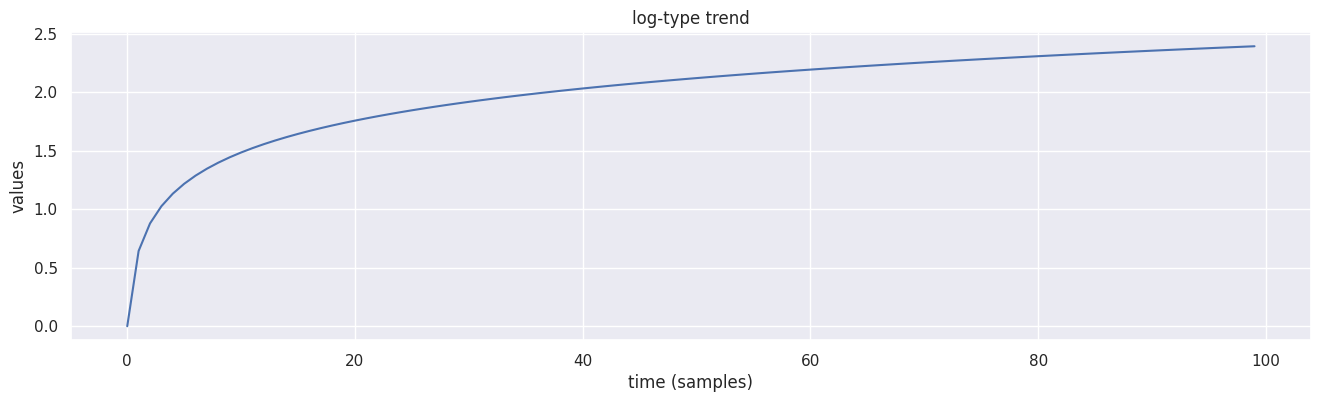

In [ ]:
N_OF_SAMPLES=100 # Number of samples
a  = 4#const
c  = 0.4
n  = np.arange(N_OF_SAMPLES)
ts = c*np.log(1+a*(n))

fig, ax = plt.subplots()
ax.plot(ts)
ax.set(xlabel='time (samples)', ylabel='values',
       title='log-type trend')
plt.show()

<font size=4  face = 'Georgia' style='Line-height : 2em'>
    
For most of the real-world series, the piecewise-monotonic behavior is natural for many real-world processes, thus it is frequently necessary to  simulate piecewise-monotonic trend with one or several inflection points.

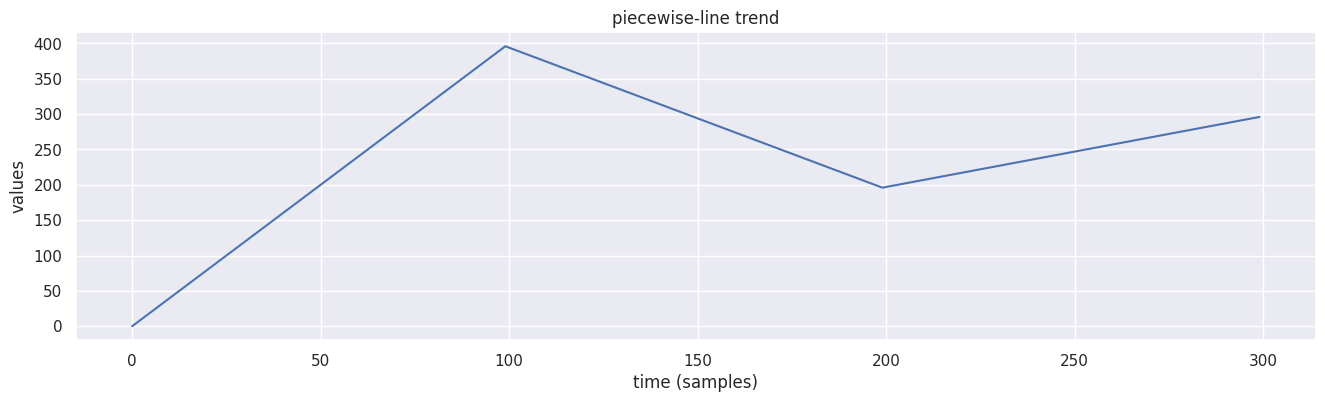

In [ ]:
N_OF_SAMPLES=100 # Number of samples

a  = 4#const
n  = np.arange(N_OF_SAMPLES)
ts1 =a*n

a  = 2#const
n  = np.arange(1,N_OF_SAMPLES+1)
ts2 = ts1[-1]-a*n

a  = 1#const
n  = np.arange(1,N_OF_SAMPLES+1)
ts3 = ts2[-1]+a*n

ts = np.concatenate((ts1,ts2,ts3))

fig, ax = plt.subplots()
ax.plot(ts)
ax.set(xlabel='time (samples)',
       ylabel='values',
       title='piecewise-line trend')
plt.show()

### 2.3 Facebook Prophet model

<font size=4  face = 'Georgia' style='Line-height : 2em'>
Let's now simulate the piecewise-line trend behavior, proposed by Facebook Prophet model,
$$y(t) = (k + a(t)^T \delta)t + m + a(t)^T \gamma, $$
where
<li> $a(t)$ is the matrix of growth changing which describe inflection points $t_j$ (matrix with ones),     
<li> $k$ is the constant growth rate,
<li> $m$ is the offset parameter,
<li> $\delta$ is a vector with growth rate adjustments,
<li> $\gamma$  is set to $\gamma_j = t_j\delta_j$,
<li> $s_j$ is the changepoint in time.   

*Notes*:
> In simplest case the model reduced to $y(t) = (k)t + m, $ for series without inflection points $t_j$.<br>
> The Prophet proposed to consider logistic model as alternative to linear one, in this case trend can be given as $y(t) = \frac{c(t)}{1+exp(-(k + a(t)^T \delta)(t-m-a^T\gamma))}$.
<!-- https://www.ritchievink.com/blog/2018/10/09/build-facebooks-prophet-in-pymc3-bayesian-time-series-analyis-with-generalized-additive-models/ -->

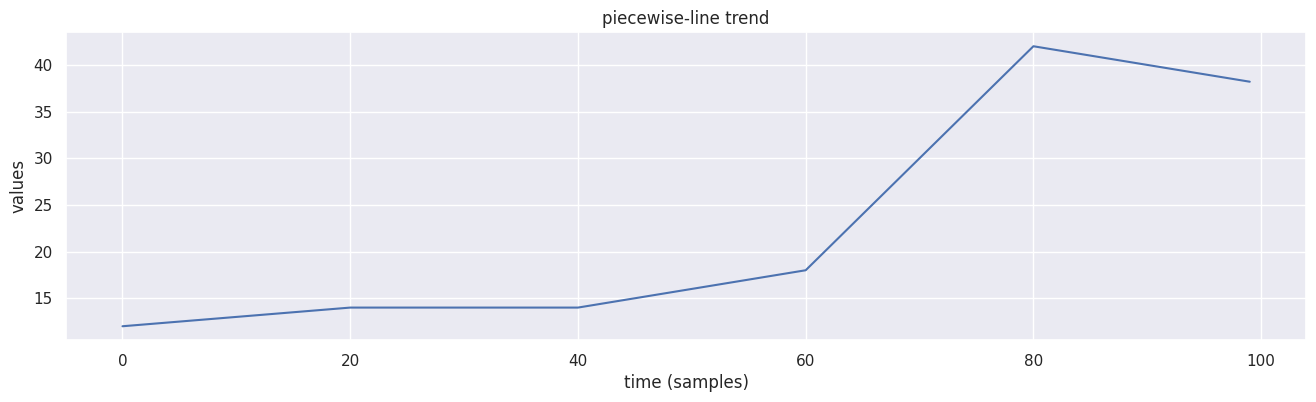

In [ ]:
N_OF_SAMPLES=100 # Number of samples

k = 0.1
m = 12

n = np.arange(N_OF_SAMPLES)

inflection_points = np.array([20, 40, 60, 80])#change points

a = np.zeros(shape=(inflection_points.size, N_OF_SAMPLES)) #  the matrix of growth changing

# fill matrix
# n[:,None] -mean add new dimention,
#(n[:,None] > inflection_points) is the logic operation to fill matrix with false, true
#(n[:,None] > inflection_points)*1 prodece 1 for true and 0 for false
a = ((n[:,None] > inflection_points) * 1).T


delta = np.array([-0.1, 0.2, 1,  -1.4])#vector with growth rate adjustments

growth = (k + np.dot(a.T,delta))

gamma = -inflection_points * delta
offset = m + np.dot(a.T,gamma)

ts = growth* n + offset


fig, ax = plt.subplots()
ax.plot(ts)
ax.set(xlabel='time (samples)',
       ylabel='values',
       title='piecewise-line trend')
plt.show()

## **Exercise 1**

<font size=4  face = 'Georgia' style='Line-height : 2em'>


1. Implement the Prophet logistic model $y(t) = \frac{c(t)}{1+\exp(-(k + a(t)^T \delta)(t-m-a^T\gamma))}$

In [ ]:
import numpy as np

def prophet_logistic_model(t, c, a, delta, m, gamma, k=0.1):
    exp_term = np.exp(-(k + np.dot(a, delta))*(t - m - np.dot(a, gamma)))
    y = c / (1 + exp_term)

    return y

# Example usage
t = 5
c = 10
a = np.array([1, 2, 3])
delta = np.array([0.5, 0.6, 0.7])
m = 12
gamma = np.array([0.2, 0.3, 0.4])

result = prophet_logistic_model(t, c, a, delta, m, gamma)
print(result)

5.705105569666646e-15


## 3. Seasonal behavior investigation

<font size=4  face = 'Georgia' style='Line-height : 2em'>
The simplest seasonal part of time series can be represented as
$$s(t) = a\cdot sin(2\pi t/T +\theta_0) = a\cdot sin(2\pi n T_s/T +\theta_0)=a \cdot sin(2\pi f n /fs +\theta_0),$$    
where:<ul>
<li>$a$ is the intensity of seasonal component;
<li>$T$ is the seasonal period (month, day, week and e.t.c.);
<li>$\theta_0$ is the initial shift (initial phase) of seasonality;
<li>$T_s$  is the sampling period;
<li>$f$ and $f_s$ are the seasonal frequency($f=1/T$) and sampling frequency $f_s = 1/T_s$.   <br>
Let's simulate this series.<br>
</ul>

<i>Note</i><br>
<li>In accordance with Shannon-Nyquist-Kotelnikov theorem minimal $f_s$ value have to be <br>$f_s\ge2f \to T \ge 2T_s$.
<li>For estimate resulted number of periods use $N_{periods} = N\cdot T_s/T $     

number of periods =  3.0


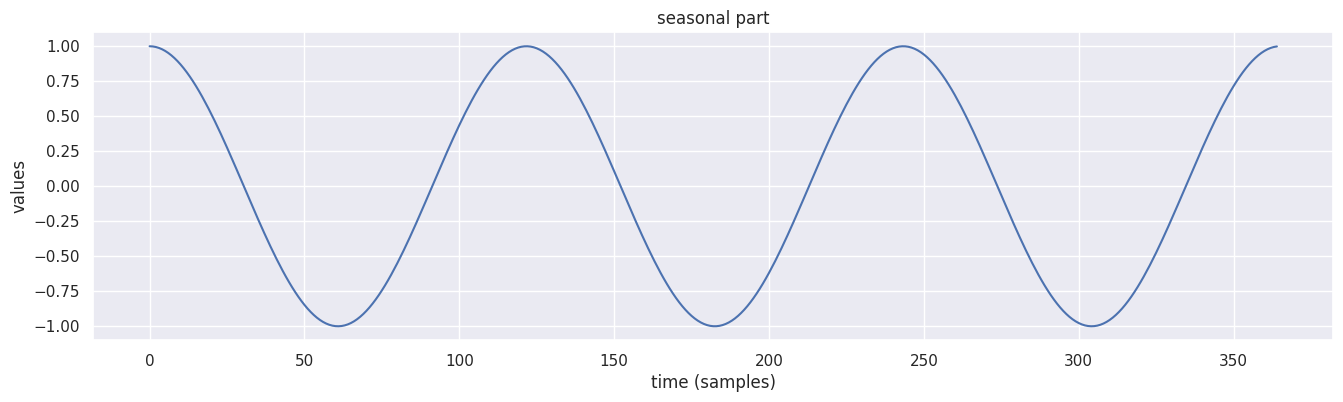

In [ ]:
N_OF_SAMPLES=365 # Number of samples

n  = np.arange(N_OF_SAMPLES)

a = 1


Ts = 1/365

T =1/3

theta = np.pi/2

print('number of periods = ',N_OF_SAMPLES*Ts/T)

ts = a*np.sin(2*np.pi*n*Ts/T+theta)

fig, ax = plt.subplots()
ax.plot(ts)
ax.set(xlabel='time (samples)',
       ylabel='values',
       title='seasonal part')
plt.show()

<font size=4  face = 'Georgia' style='Line-height : 2em'>
Let's now simulate more complex seasonality per year, like a month and a week one, we will make additively, such that:
 $$seasonality=\sum_{i=0}^{M}a_i\cdot sin(2\pi n T_s/T_i +\theta_i)$$

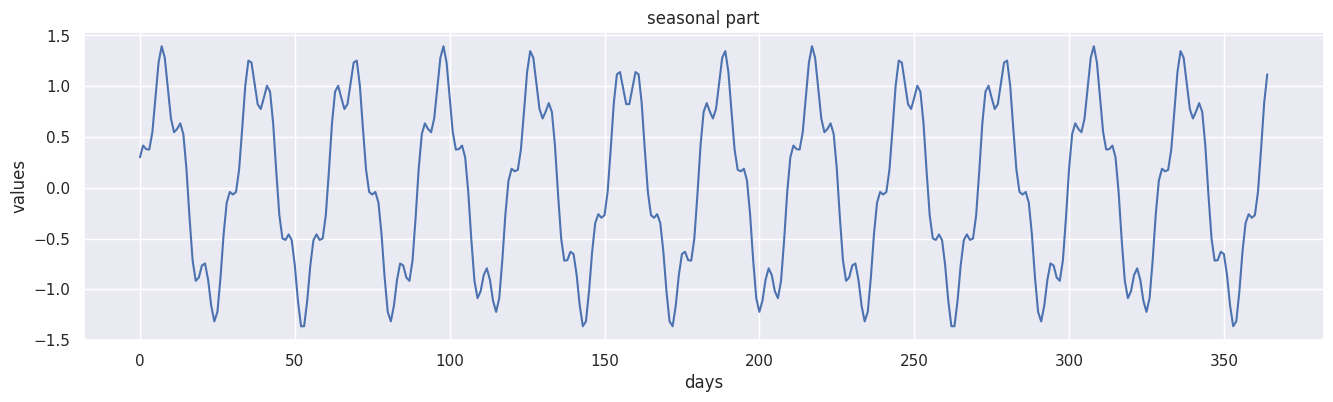

In [ ]:
N_OF_DAYS=365# Number of samples

days  = np.arange(N_OF_DAYS)

a_w = 0.3 #weak influence

a_m = 1.1 #month influence

T_w = 7/365

T_m = 30/365

Ts = 1/365

theta_w = np.pi/2

theta_m = 0

ts = a_w*np.sin(2*np.pi*days*Ts/T_w + theta_w)+a_m*np.sin(2*np.pi*days*Ts/T_m + theta_m)

fig, ax = plt.subplots()
ax.plot(ts)
ax.set(xlabel='days',
       ylabel='values',
       title='seasonal part')
plt.show()

## **Exercise 2**



- [1] For the previous model add quarter (3 month) seasonality.

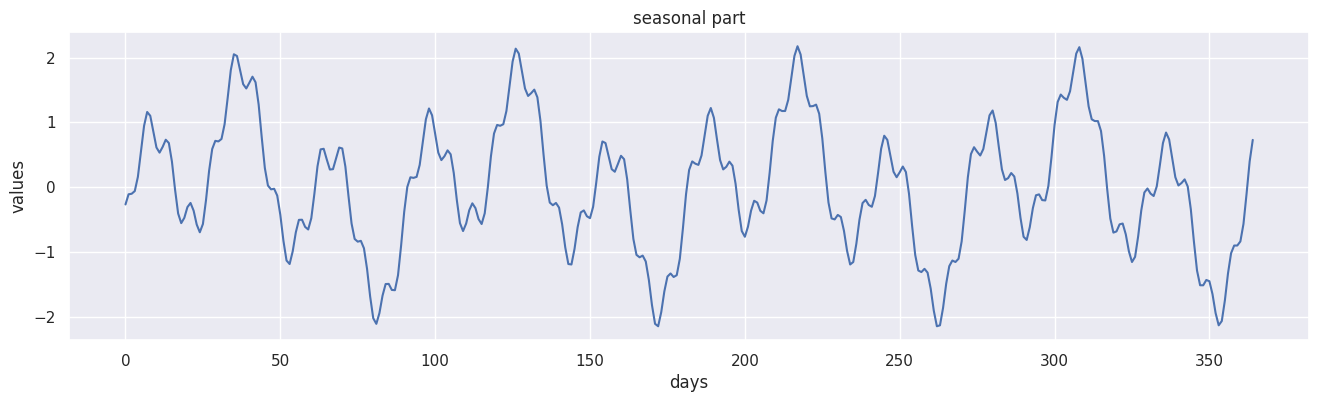

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

N_OF_DAYS = 365 # Number of samples
days = np.arange(N_OF_DAYS)

a_w = 0.3 # weak influence
a_m = 1.1 # month influence
a_3m = 0.8 # 3-month influence

T_w = 7/365
T_m = 30/365
T_3m = 90/365

Ts = 1/365

theta_w = np.pi/2
theta_m = 0
theta_3m = -np.pi/4

ts = a_w*np.sin(2*np.pi*days*Ts/T_w + theta_w) + a_m*np.sin(2*np.pi*days*Ts/T_m + theta_m) + a_3m*np.sin(2*np.pi*days*Ts/T_3m + theta_3m)

fig, ax = plt.subplots()
ax.plot(ts)
ax.set(xlabel='days',
       ylabel='values',
       title='seasonal part')
plt.show()


## 4. Simulation of additive and multiplicative Time Series

<font size=4  face = 'Georgia' style='Line-height : 2em'>
 Now we are able to simulate additive and multiplicative time series
    $$y(t) = seasonality(t)+trend(t)$$
 In our case it will be implemented as
 $$y(t)  =  bias_{trend} + a_{trend}nT_s + a_m\cdot sin(2\pi n T_s/T_m )+ a_w\cdot sin(2\pi n T_s/T_w ) $$

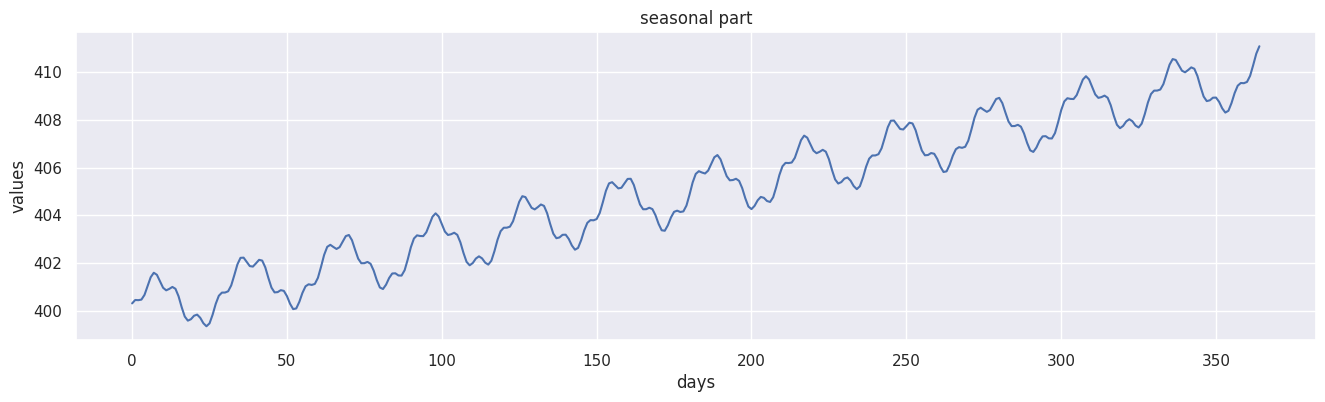

In [ ]:
YEAR = 365

WEEK = 7

MONTH = 30

N_OF_DAYS=YEAR# Number of samples

days  = np.arange(N_OF_DAYS)

a_w = 0.3 #weak influence

a_m = 1.1 #month influence

T_w = WEEK/YEAR

T_m = MONTH/YEAR

Ts = 1/YEAR

theta_w = np.pi/2

theta_m = 0

a_trend = 10 #slope

bias_trend = 400

trend = a_trend*days*Ts+bias_trend

seasonality = a_w*np.sin(2*np.pi*days*Ts/T_w + theta_w)+a_m*np.sin(2*np.pi*days*Ts/T_m + theta_m)

ts =trend + seasonality

fig, ax = plt.subplots()
ax.plot(ts)
ax.set(xlabel='days',
       ylabel='values',
       title='seasonal part')
plt.show()

## **Exercise 3**

<!--<font size=4  face = 'Georgia' style='Line-height : 2em'>-->

- [1] Implement multiplicative deterministic time series model with seasonal and trend part.
- [2] Learn how logistic trend with additive seasonality will be look-like.




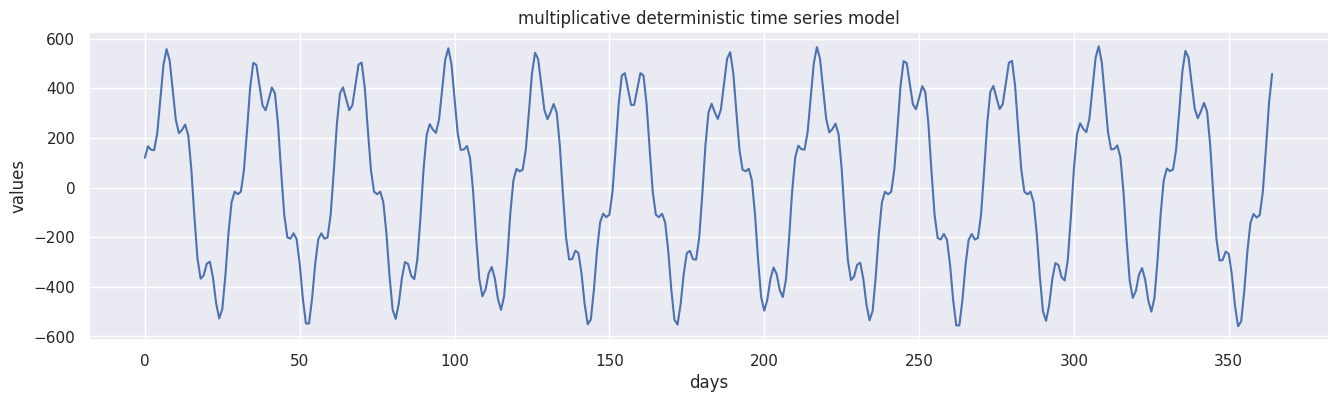

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

YEAR = 365
WEEK = 7
MONTH = 30
N_OF_DAYS = YEAR

days = np.arange(N_OF_DAYS)

a_w = 0.3 # weak influence
a_m = 1.1 # month influence

T_w = WEEK/YEAR
T_m = MONTH/YEAR
Ts = 1/YEAR

theta_w = np.pi/2
theta_m = 0

a_trend = 10 # slope
bias_trend = 400

trend = a_trend * days * Ts + bias_trend


seasonality = a_w*np.sin(2*np.pi*days*Ts/T_w + theta_w)+a_m*np.sin(2*np.pi*days*Ts/T_m + theta_m)


ts = trend * seasonality

fig, ax = plt.subplots()
ax.plot(ts)
ax.set(xlabel='days', ylabel='values', title='multiplicative deterministic time series model')
plt.show()

## 5. Cyclic pattern is the part of trend

Beside trend and seasonality we can add some cyclic (alternatively can be considered as addition trend behavior).

Let's simulate it as some year-season relation, for instance in the example below we simulate drop of sales in the middle of the year (in summer).

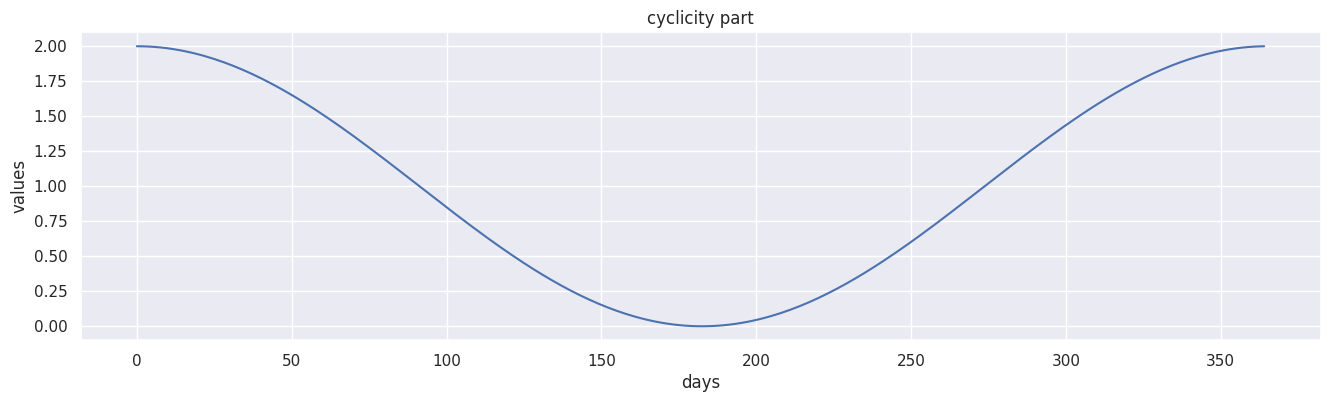

In [ ]:
a_cycl = 1
T_cycl = 1
cyclicity = a_cycl +a_cycl *np.sin(2*np.pi*days*Ts/T_cycl + np.pi/2)

ts =cyclicity

fig, ax = plt.subplots()
ax.plot(ts)
ax.set(xlabel='days',
       ylabel='values',
       title='cyclicity part')
plt.show()

<font size=4  face = 'Georgia' style='Line-height : 2em'>
Now we can add it to the linear trend


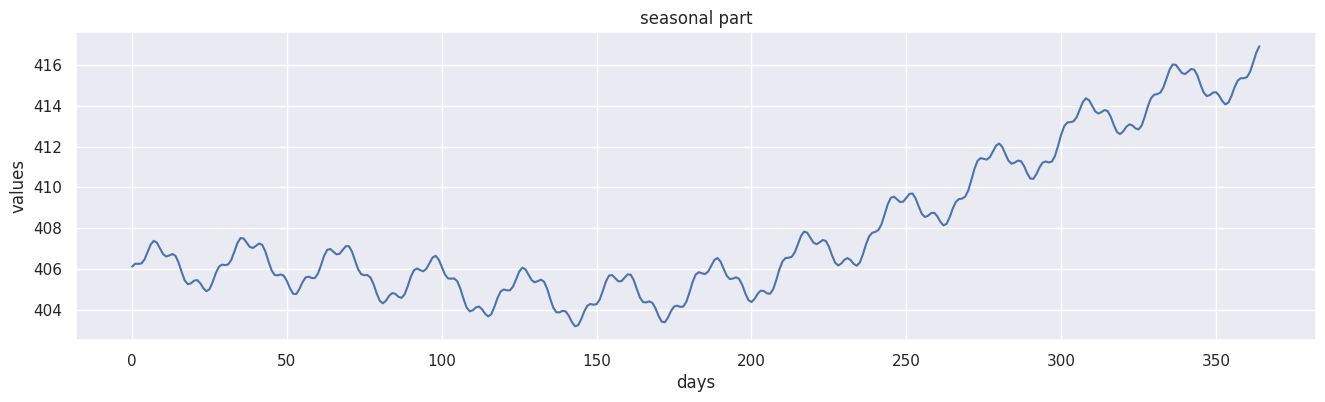

In [ ]:
YEAR = 365

WEEK = 7

MONTH = 30

N_OF_DAYS=YEAR# Number of samples

days  = np.arange(N_OF_DAYS)

a_w = 0.3 #weak influence

a_m = 1.1 #month influence

T_w = WEEK/YEAR

T_m = MONTH/YEAR

Ts = 1/YEAR

theta_w = np.pi/2

theta_m = 0

a_trend = 10 #slope

bias_trend = 400

trend = a_trend*days*Ts+bias_trend

seasonality = a_w*np.sin(2*np.pi*days*Ts/T_w + theta_w)+a_m*np.sin(2*np.pi*days*Ts/T_m + theta_m)

a_cycl = 2.91
T_cycl = 1
cyclicity = a_cycl+a_cycl *np.sin(2*np.pi*days*Ts/T_cycl + np.pi/2)

ts =trend + seasonality + cyclicity

fig, ax = plt.subplots()
ax.plot(ts)
ax.set(xlabel='days',
       ylabel='values',
       title='seasonal part')
plt.show()

## **Exercise 4**

- [1] Implement multiplicative deterministic time series model with seasonal, cyclic and trend part.

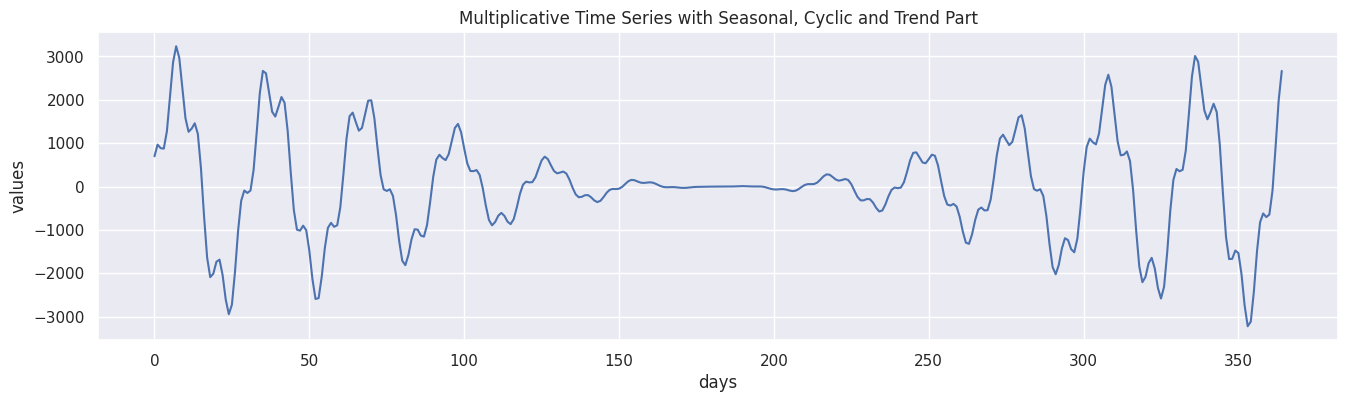

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

YEAR = 365
WEEK = 7
MONTH = 30
N_OF_DAYS = YEAR

days = np.arange(N_OF_DAYS)

a_w = 0.3
a_m = 1.1
T_w = WEEK/YEAR
T_m = MONTH/YEAR
Ts = 1/YEAR
theta_w = np.pi/2
theta_m = 0
a_trend = 10
bias_trend = 400

trend = a_trend * days * Ts + bias_trend

seasonality = a_w*np.sin(2*np.pi*days*Ts/T_w + theta_w)+a_m*np.sin(2*np.pi*days*Ts/T_m + theta_m)

a_cycl = 2.91
T_cycl = 1
cyclicity = a_cycl+a_cycl *np.sin(2*np.pi*days*Ts/T_cycl + np.pi/2)

ts = trend * seasonality * cyclicity

fig, ax = plt.subplots()
ax.plot(ts)
ax.set(xlabel='days', ylabel='values', title='Multiplicative Time Series with Seasonal, Cyclic and Trend Part')
plt.show()

## 6. Specific event simulation

<font size=4  face = 'Georgia' style='Line-height : 2em'>
Beside the trend and regular seasonality the specific events can be introduced to the time series model.    <br>
For instance, if we simulate sales time series it will be interesting to add some week-days demand change.  <br>
In simplest case it can be done as following:
    $$\text{week_days}(day) = \sum_{i=1}^7a_i\delta(\lfloor{(day-1)/7}\rfloor+1-i),$$
Where <ul>
<li>    $\lfloor{day/7}\rfloor$ - mean the rest of the division;
<!--     <ul> for test try: <code class="language-python">
        print(np.arange(1,8))
(7*50+np.arange(1,8)-1)%7+1        </code></ul> -->
<li>    $\delta$ is the Kronecker delta function, $$\delta (i,j)= \delta (i-j)= \begin{cases}   1 &\text{if}i=j\\
   0 &\text{otherwise}
 \end{cases}$$
<li>    i is the day number ($i = 1,2,3,4,5,6,7$).
 </ul>  

*Note* If you want to count days not from the first use
$$\text{week_days}(day) = \sum_{i=1}^7a_i\delta(\lfloor{(day-1 + shift-1 )/7}\rfloor+1-i),$$
where shift is the number of days to be shifted.<br>
Let's check this result

In [ ]:
N_OF_DAYS =14
shift = 1
days = np.arange(1,N_OF_DAYS+1)
print((days-1+(shift-1))%7+1)


[1 2 3 4 5 6 7 1 2 3 4 5 6 7]


<font size=4  face = 'Georgia' style='Line-height : 2em'>
For simulation the week-days behavior we will use $a_{week}$ set of 7 coefficients

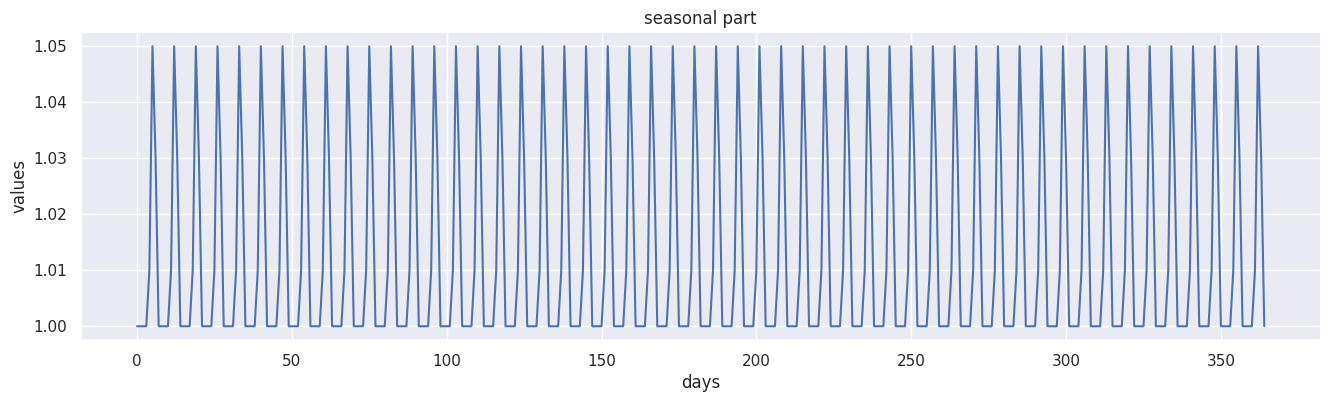

In [ ]:
N_OF_DAYS=365

days  = np.arange(N_OF_SAMPLES)

# week days coefficients
a_week = np.array([1, 1, 1, 1, 1.01, 1.05, 1.03])

#for the number of days multiples of the week
week_days = list(a_week)*int(N_OF_DAYS/7)

# add rest of the days
week_days = np.array([*week_days,*a_week[:N_OF_DAYS%7]])

#check that week_days size equal to N_OF_DAYS
assert week_days.size==N_OF_DAYS

ts = week_days

fig, ax = plt.subplots()
ax.plot(ts)
ax.set(xlabel='days',
       ylabel='values',
       title='seasonal part')
plt.show()

<font size=4  face = 'Georgia' style='Line-height : 2em'>
    
For simulation week-days influence on the linear we can introduce the following model
$$
y(day)  = bias_{trend} + a_{trend}day + a_{trend}\text{wee_days_coefficients}  = \\
y(day) = trend + \text{week_days},$$
where $\text{week_days}$ is the week-days simulation including trend

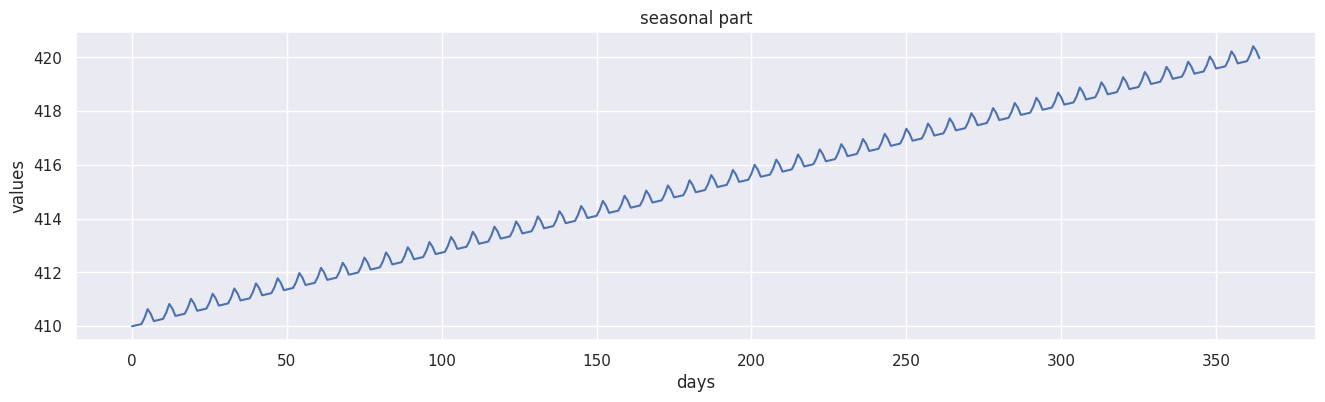

In [ ]:
N_OF_DAYS = 365
days      = np.arange(N_OF_SAMPLES)

a_trend    = 10 #slope
bias_trend = 400
week_coefficients = np.array([1, 1, 1, 1, 1.02, 1.05, 1.03])

a_week = week_coefficients*a_trend

week_days = np.array([*list(a_week)*int(N_OF_DAYS/7), *a_week[:N_OF_DAYS%7]])

trend = a_trend*n*Ts+bias_trend

ts =week_days + trend

fig, ax = plt.subplots()
ax.plot(ts)
ax.set(xlabel='days',
       ylabel='values',
       title='seasonal part')
plt.show()

<font size=4  face = 'Georgia' style='Line-height : 2em'>
Let's now add seasonality part and make a model for two years with logistic trend.

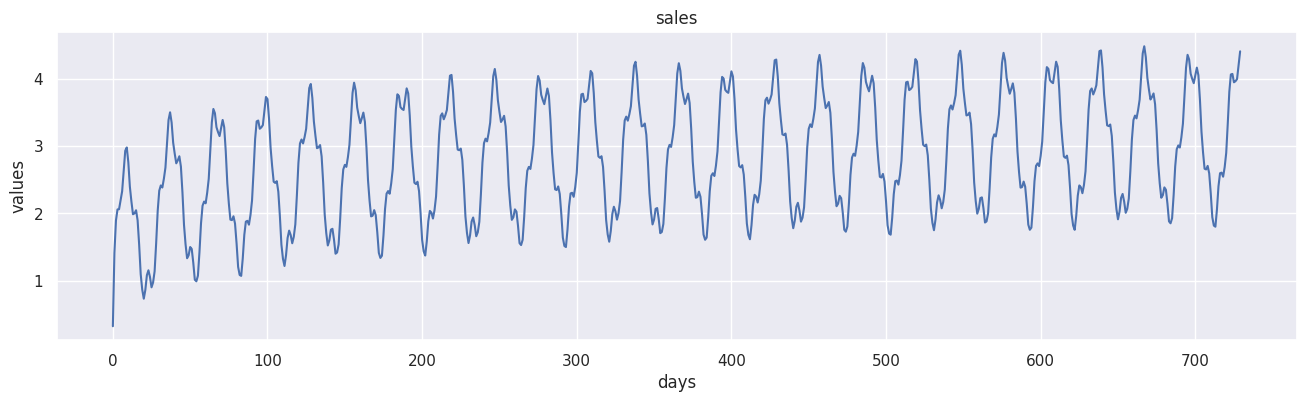

In [ ]:
YEAR = 365

WEEK = 7

MONTH = 30

N_OF_DAYS=YEAR*2# Number of samples

days  = np.arange(N_OF_DAYS)

a_w = 0.3 #weak influence

a_m = 1.1 #month influence

T_w = WEEK/YEAR

T_m = MONTH/YEAR

Ts = 1/YEAR

a_trend = 5
c_trend = 0.34

week_coefficients = np.array([0.95, 1, 1, 1, 1, 1.25, 1.03])

a_week = week_coefficients*c_trend

trend = c_trend*np.log(1+a_trend*days)

seasonality = a_w*np.sin(2*np.pi*days*Ts/T_w )+a_m*np.sin(2*np.pi*days*Ts/T_m )


week_days = np.array([*list(a_week)*int(N_OF_DAYS/7), *a_week[:N_OF_DAYS%7]])


ts    = week_days + trend  + seasonality

fig, ax = plt.subplots()
ax.plot(ts)
ax.set(xlabel='days',
       ylabel='values',
       title='sales')
plt.show()

## **Exercise 5**

- [1] Add the holidays drop of demand in the start of the year to the time series implemented above  

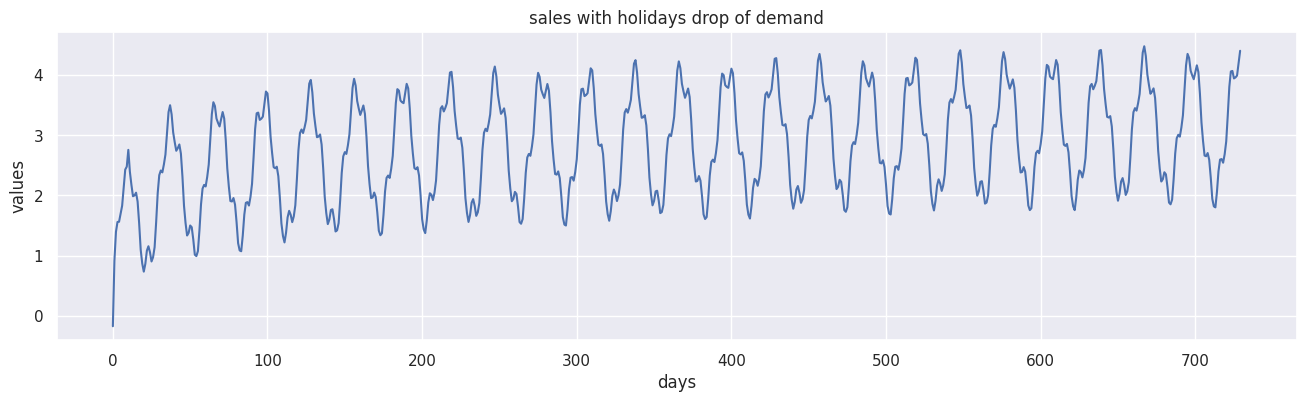

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

YEAR = 365
WEEK = 7
MONTH = 30
N_OF_DAYS = YEAR*2  # Number of samples

days = np.arange(N_OF_DAYS)

a_w = 0.3  # weak influence
a_m = 1.1  # month influence

T_w = WEEK/YEAR
T_m = MONTH/YEAR
Ts = 1/YEAR

a_trend = 5
c_trend = 0.34

week_coefficients = np.array([0.95, 1, 1, 1, 1, 1.25, 1.03])

a_week = week_coefficients*c_trend

trend = c_trend*np.log(1+a_trend*days)

seasonality = a_w*np.sin(2*np.pi*days*Ts/T_w) + a_m*np.sin(2*np.pi*days*Ts/T_m)

week_days = np.array([*list(a_week)*int(N_OF_DAYS/7), *a_week[:N_OF_DAYS % 7]])

ts = week_days + trend + seasonality

# Adding holidays drop of demand
holidays_effect = np.zeros(N_OF_DAYS)
holiday_duration = 10

# Creating holidays drop of demand in the first 20 days
holidays_effect[:holiday_duration] = -0.5  # 50% drop in demand during holidays

ts_with_holidays = ts + holidays_effect

fig, ax = plt.subplots()
ax.plot(ts_with_holidays)
ax.set(xlabel='days',
       ylabel='values',
       title='sales with holidays drop of demand')
plt.show()


## 7. Noise simulation

### White Gaussian Noise


<font size=4  face = 'Georgia' style='Line-height : 2em'>
    
Beside the deterministic part of time, it is valuable to simulate it stochastic behavior.<br>
The stochastic behavior of the time series firstly connected with noise influence.<br>
The most simple and the most common model of the noise is the<br>
<b>White Gaussian Noise (WGN)</b> (almost equal to the <b>independent and identically distributed (i.i.d) </b> noise model ).<br>
WGN has the normal distribution with zero mean value and :
$$
\begin{align}
   & noise(t) \sim N(0,\sigma); & \small{\text{noise is random values with normal distribution}} \\
   & P(t) = N(0,\sigma)  = \frac{1}{\sigma\sqrt{2\pi}}exp{(\frac{-t^2}{2\sigma^2})}& \small{\text{normal distribution with zero mean and variance $\sigma^2$}}
\end{align}
$$    
where $\sigma$ is noise power - standard deviation of noises (square root of it variance).<br>
Let's simulate White Gaussian Noise

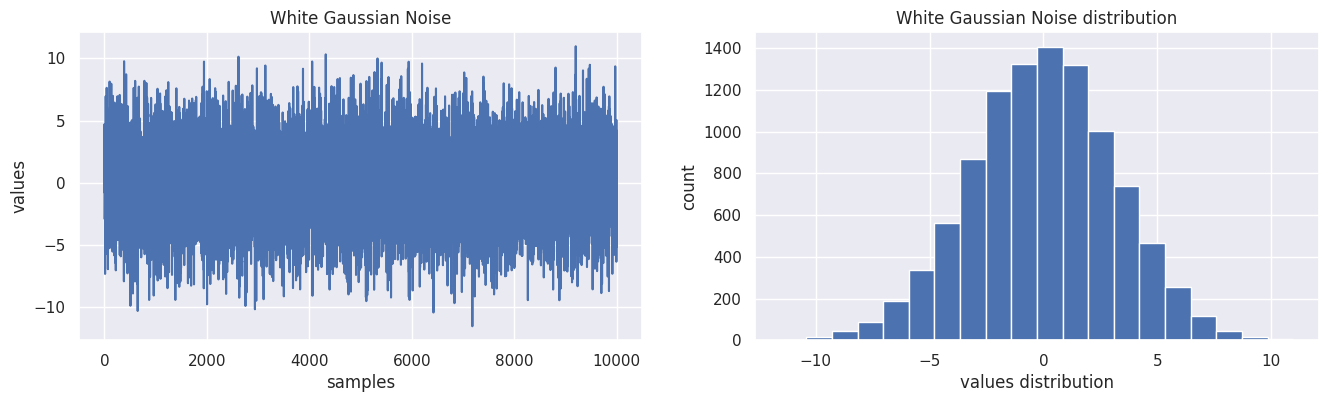

In [ ]:
N_OF_SAMPLES = 10000

noise_power  = 10

wgn = np.sqrt(noise_power)*np.random.normal(size = N_OF_SAMPLES)

ts = wgn

fig, ax = plt.subplots(1,2)

ax[0].plot(ts)
ax[0].set(xlabel='samples',
       ylabel='values',
       title='White Gaussian Noise')

ax[1].hist(ts, bins = 20)
ax[1].set(xlabel='values distribution',
       ylabel='count',
       title='White Gaussian Noise distribution')
plt.show()

<font size=4  face = 'Georgia' style='Line-height : 2em'>
So we can see how noise influence on the time series

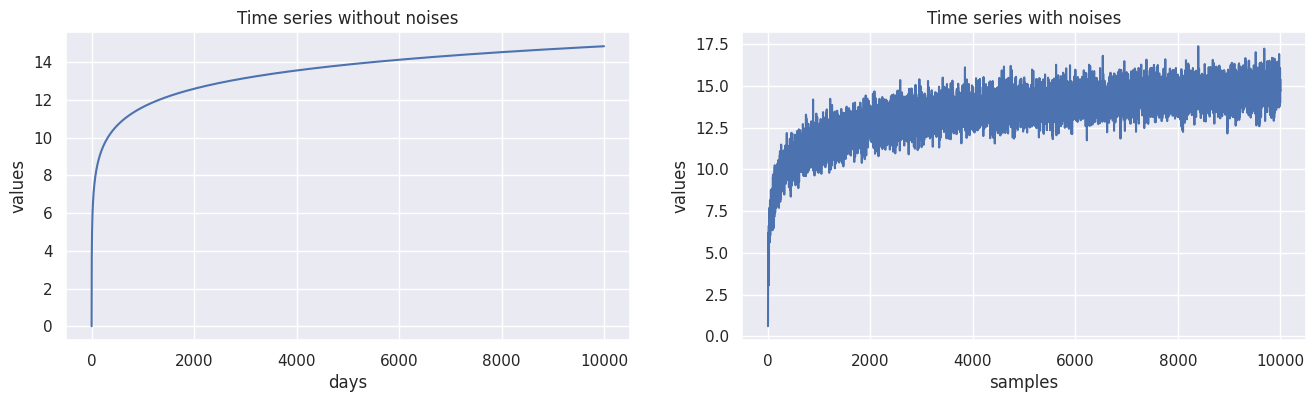

In [ ]:
N_OF_SAMPLES = 10000

noise_power  = 0.5

wgn = (np.sqrt(noise_power))*(np.random.normal(size = N_OF_SAMPLES))

a  = 4#const
c  = 1.4
n  = np.arange(N_OF_SAMPLES)
ts = c*np.log(1+a*(n))

ts_wn = ts + wgn

fig, ax = plt.subplots(1,2)

ax[0].plot(ts)
ax[0].set(xlabel='days',
       ylabel='values',
       title='Time series without noises')

ax[1].plot(ts_wn)
ax[1].set(xlabel='samples',
       ylabel='values',
       title='Time series with noises')
plt.show()

<font size=4  face = 'Georgia' style='Line-height : 2em'>
Beside the identically distributed noise that corresponds to the stationary noise model,<br>
it is important to simulate non-stationary cases.<br>
The most simple case is the linearly increasing variation,    

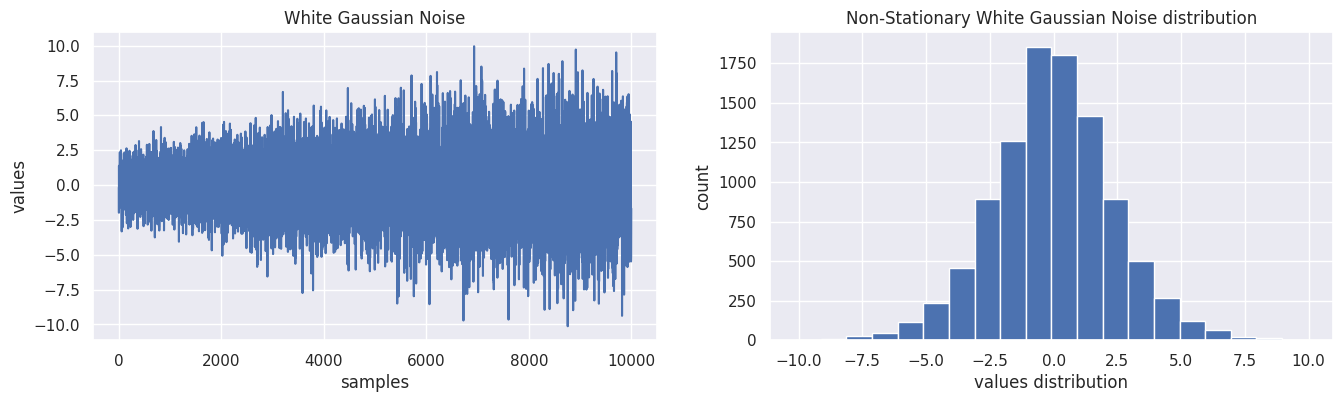

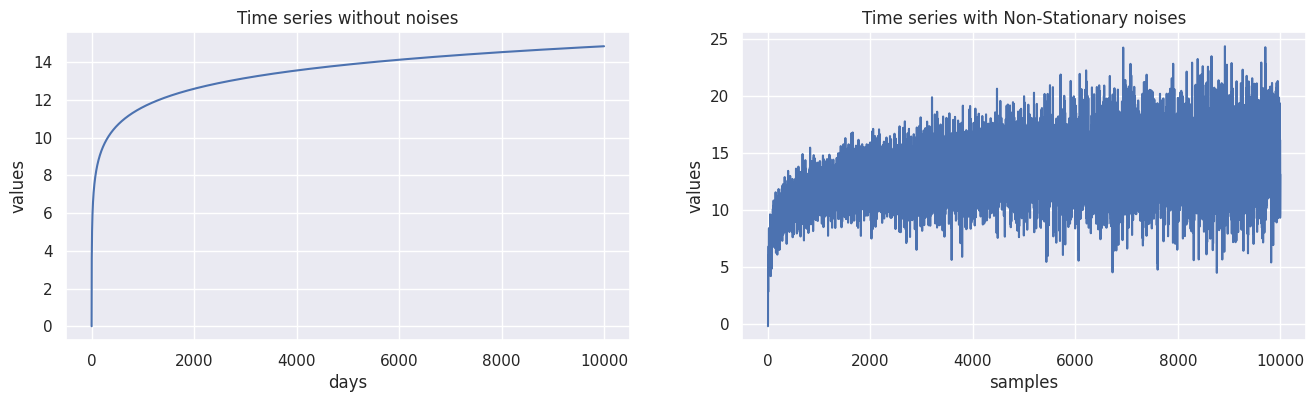

In [ ]:
N_OF_SAMPLES = 10000
a  = 4#const
c  = 1.4

noise_power  = np.linspace(1,10,N_OF_SAMPLES) #linearly growing noise power

wgn = np.sqrt(noise_power)*np.random.normal(size = N_OF_SAMPLES)

ts = c*np.log(1+a*np.arange(N_OF_SAMPLES))

ts_wn = ts + wgn

fig, ax = plt.subplots(1,2)

ax[0].plot(wgn)
ax[0].set(xlabel='samples',
       ylabel='values',
       title='White Gaussian Noise')

ax[1].hist(wgn, bins = 20)
ax[1].set(xlabel='values distribution',
       ylabel='count',
       title='Non-Stationary White Gaussian Noise distribution')
fig, ax = plt.subplots(1,2)
ax[0].plot(ts)
ax[0].set(xlabel='days',
       ylabel='values',
       title='Time series without noises')

ax[1].plot(ts_wn)
ax[1].set(xlabel='samples',
       ylabel='values',
       title='Time series with Non-Stationary noises')
plt.show()

## **Exercise 6**

<font size=4  face = 'Georgia' style='Line-height : 2em'>

- [1] Investigate  the stationary and non-stationary additive white noise influence on the time series with seasonal and trend parts, in the following form
$$ y(t) = a_0 + trend(t) +seasonal(t) + cyclic(t) + \text{rare_events(t)}+ noise(t). $$

- [2] Simulate more complex time series model in the form
$$y(t) = a_0 + (trend(t) \cdot cyclic(t) + seasonal_1(t))\cdot seasonal_2(t) + noise(t).$$

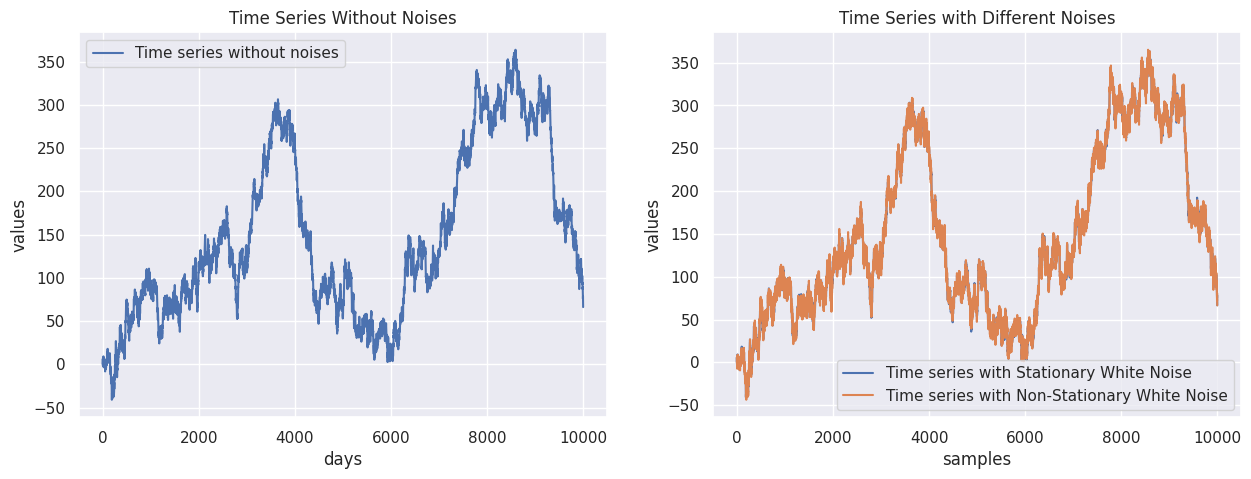

In [ ]:
# For stationary white noise
stationary_wgn = 0.5 * np.random.normal(size=N_OF_SAMPLES)  # Mean value of 0.5
ts_stationary_wn = ts + stationary_wgn

# For non-stationary white noise
non_stationary_wgn = np.sqrt(noise_power) * np.random.normal(size=N_OF_SAMPLES)
ts_non_stationary_wn = ts + non_stationary_wgn

# Plotting the time series with and without noises
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].plot(ts, label='Time series without noises')
ax[0].set(xlabel='days', ylabel='values', title='Time Series Without Noises')
ax[0].legend()

ax[1].plot(ts_stationary_wn, label='Time series with Stationary White Noise')
ax[1].plot(ts_non_stationary_wn, label='Time series with Non-Stationary White Noise')
ax[1].set(xlabel='samples', ylabel='values', title='Time Series with Different Noises')
ax[1].legend()

plt.show()

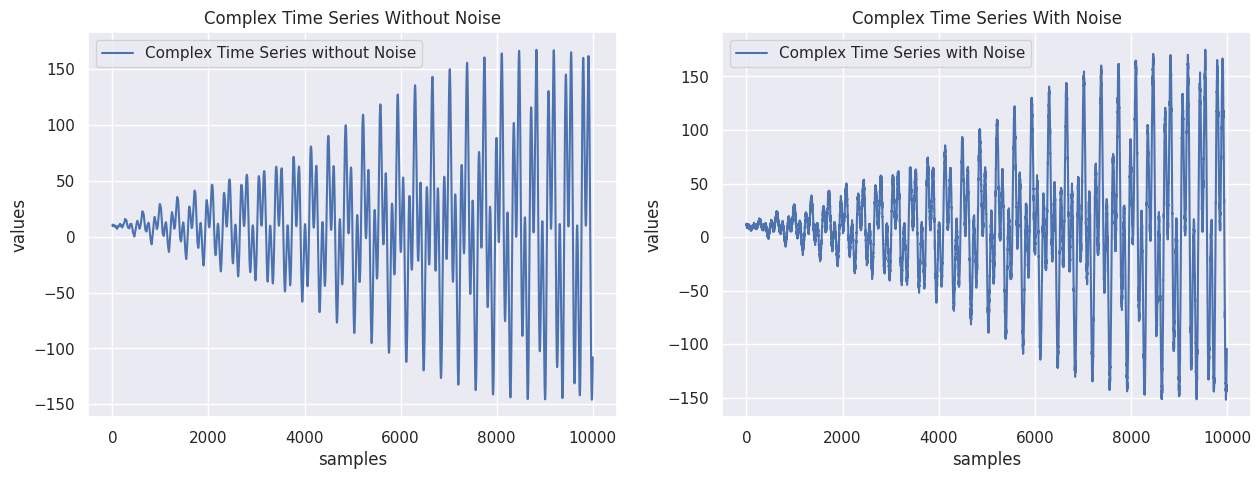

In [ ]:
# Complex time series model
t = np.arange(N_OF_SAMPLES)
trend = 0.02 * t  # Linear trend
cyclic = np.sin(2 * np.pi * t / 365)  # Cyclic component
seasonal_1 = np.sin(2 * np.pi * t / 30)  # Seasonal component
seasonal_2 = np.cos(2 * np.pi * t / 180)  # Another seasonal component

complex_ts = 10 + (trend * cyclic + seasonal_1) * seasonal_2  # Applying the complex model
noise_power = np.linspace(1, 10, N_OF_SAMPLES)
complex_wgn = np.sqrt(noise_power) * np.random.normal(size=N_OF_SAMPLES)

complex_ts_wn = complex_ts + complex_wgn

# Plotting the complex time series with and without noise
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].plot(complex_ts, label='Complex Time Series without Noise')
ax[0].set(xlabel='samples', ylabel='values', title='Complex Time Series Without Noise')
ax[0].legend()

ax[1].plot(complex_ts_wn, label='Complex Time Series with Noise')
ax[1].set(xlabel='samples', ylabel='values', title='Complex Time Series With Noise')
ax[1].legend()

plt.show()

## 8. Random Walk Trend

<font size=4  face = 'Georgia' style='Line-height : 2em'>
Beside the only additive noise the important noise model is random walk, which in the simplest case can be simulated as
    $$y(t) = y(t-1)+\eta(t),$$
where $\eta(t)\sim N(0,\sigma^2)$<br>
The model is widespread in many business process investigation.

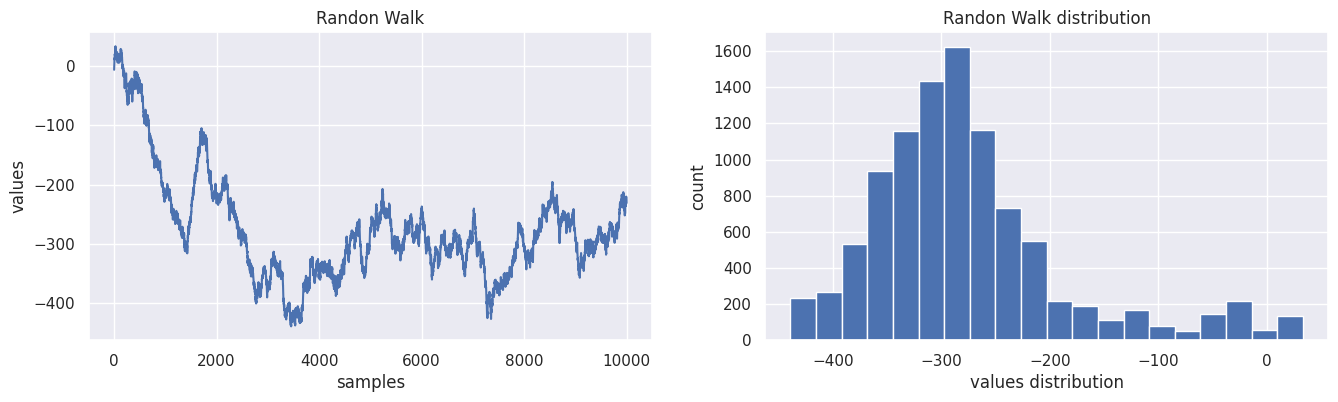

In [ ]:
N_OF_SAMPLES = 10000

noise_power  = 10

wgn = np.sqrt(noise_power)*np.random.normal(size = N_OF_SAMPLES)

ts = np.cumsum(wgn )

fig, ax = plt.subplots(1,2)

ax[0].plot(ts)
ax[0].set(xlabel='samples',
       ylabel='values',
       title='Randon Walk')

ax[1].hist(ts, bins = 20)
ax[1].set(xlabel='values distribution',
       ylabel='count',
       title='Randon Walk distribution')
plt.show()

## **Exercise 7**

<font size=4  face = 'Georgia' style='Line-height : 2em'>

- [1] Investigate 3 another random walk models: <br>
-- [1.1] Random walk with drift $y(t) =\alpha + y(t-1) + \eta(t) $   <br>
-- [1.2] Random walk with trend $y(t) =\alpha + \beta\cdot t + y(t-1) + \eta(t) $ <br>
-- [1.3] Random walk with growing intensity<br> $y(t) = y(t-1) + \eta(t) , \\ \eta(t)\sim N(0, \sigma^2(t)),\\ \sigma^2(t) = \sigma_0 + \gamma\cdot t $

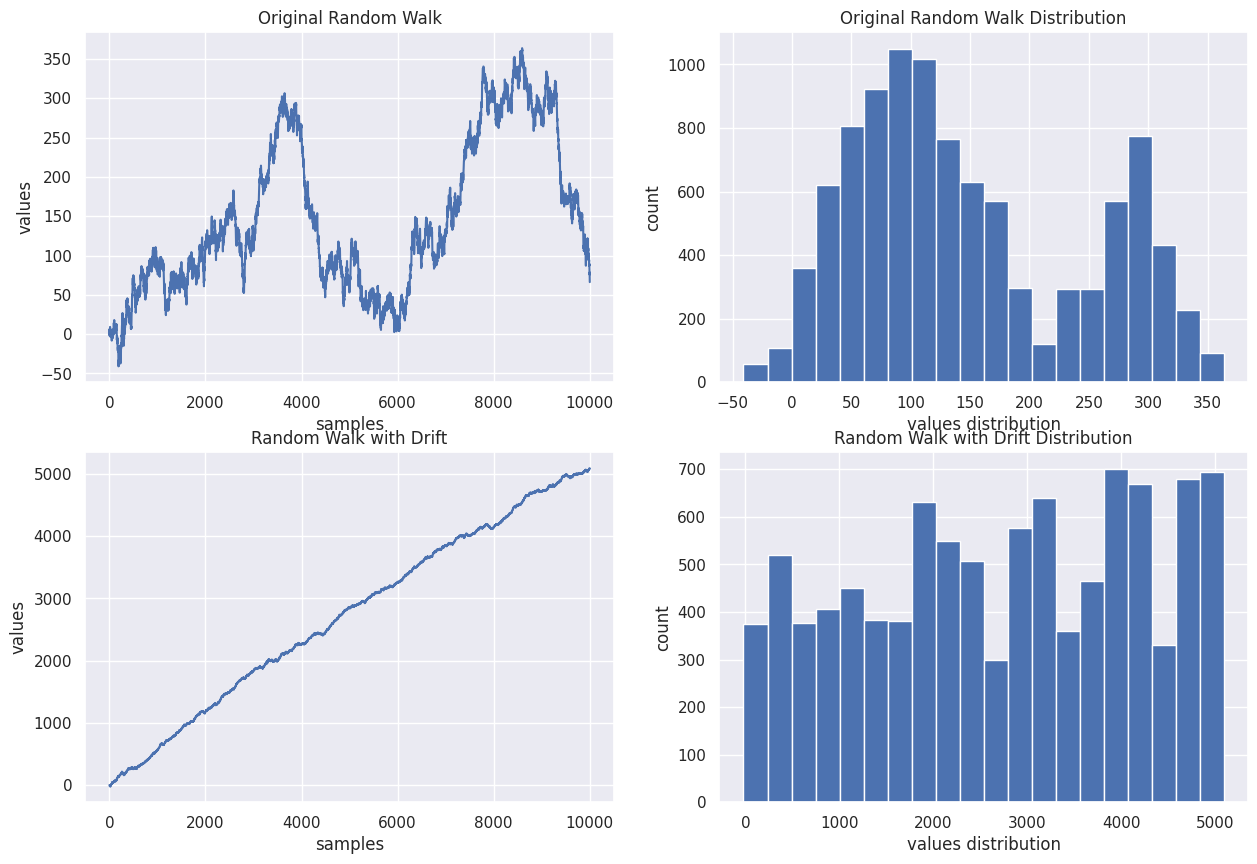

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

N_OF_SAMPLES = 10000
noise_power = 10

# Original random walk
wgn = np.sqrt(noise_power) * np.random.normal(size=N_OF_SAMPLES)
ts = np.cumsum(wgn)

fig, ax = plt.subplots(2, 2, figsize=(15, 10))

# Plotting original random walk
ax[0, 0].plot(ts)
ax[0, 0].set(xlabel='samples', ylabel='values', title='Original Random Walk')

ax[0, 1].hist(ts, bins=20)
ax[0, 1].set(xlabel='values distribution', ylabel='count', title='Original Random Walk Distribution')

# Random walk with drift y(t) = α + y(t-1) + η(t)
alpha = 0.5
wgn_drift = np.sqrt(noise_power) * np.random.normal(size=N_OF_SAMPLES)
ts_drift = np.zeros(N_OF_SAMPLES)
for i in range(1, N_OF_SAMPLES):
    ts_drift[i] = alpha + ts_drift[i - 1] + wgn_drift[i]

ax[1, 0].plot(ts_drift)
ax[1, 0].set(xlabel='samples', ylabel='values', title='Random Walk with Drift')

ax[1, 1].hist(ts_drift, bins=20)
ax[1, 1].set(xlabel='values distribution', ylabel='count', title='Random Walk with Drift Distribution')

plt.show()